In [3]:
import os
import sys

import numpy as np
import pickle

import scipy as sp
import scipy.stats as st

import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

from colorsys import hls_to_rgb

import mplot as mp

import seaborn as sns 

#import logomaker as lm

from matplotlib.lines import Line2D


# Plot variables
FIG_DPI = 600

COLOR_1  = '#1295D8'
COLOR_2  = '#FFB511'
BKCOLOR  = '#252525'
LCOLOR   = '#969696'
C_BEN    = '#EB4025' #'#F16913'
C_BEN_LT = '#F08F78' #'#fdd0a2'
C_NEU    =  LCOLOR   #'#E8E8E8' # LCOLOR
C_NEU_LT = '#E8E8E8' #'#F0F0F0' #'#d9d9d9'
C_DEL    = '#3E8DCF' #'#604A7B'
C_DEL_LT = '#78B4E7' #'#dadaeb'
C_POP  = C_DEL
C_PREF = LCOLOR

cm2inch = lambda x: x/2.54
SINGLE_COLUMN   = cm2inch(8.8)
ONE_FIVE_COLUMN = cm2inch(11.4)
DOUBLE_COLUMN   = cm2inch(18.0)
SLIDE_WIDTH     = 10.5
GOLDR           = (1.0 + np.sqrt(5)) / 2.0

# paper style
FONTFAMILY    = 'Arial'
SIZESUBLABEL  = 11
SIZELABEL     = 11
SIZETICK      = 11
SMALLSIZEDOT  = 6.
SIZELINE      = 0.6
AXES_FONTSIZE = 6
AXWIDTH       = 0.4

# # grant style
# FONTFAMILY    = 'Arial'
# SIZESUBLABEL  = 12
# SIZELABEL     = 8
# SIZETICK      = 8
# SMALLSIZEDOT  = 6. * 1.3
# SIZELINE      = 0.6
# AXES_FONTSIZE = 8
# AXWIDTH       = 0.4

DEF_SUBLABEL = {
    'family': FONTFAMILY,
    'size':   SIZESUBLABEL,
    'weight': 'bold'
}

DEF_ERRORPROPS = {
    'mew'        : AXWIDTH,
    'markersize' : SMALLSIZEDOT/2,
    'fmt'        : 'o',
    'elinewidth' : SIZELINE/2,
    'capthick'   : 0,
    'capsize'    : 0
}

DEF_LABELPROPS = {
    'family' : FONTFAMILY,
    'size'   : SIZELABEL,
    'color'  : 'k',
    'clip_on': False
}

DEF_TEXTPROPS = {
    'family' : FONTFAMILY,
    'size'   : SIZELABEL
}

FIGPROPS = {
    'transparent' : True,
    'dpi'         : FIG_DPI,
    #'bbox_inches' : 'tight'
}

matplotlib.rc('font', **DEF_TEXTPROPS)

FIG_DIR  = './figures/'
PREF_DIR = './output/merged_preference/'
POP_DIR  = './output/selection_coefficients/'

COL_SITE = 'site'
COL_AA   = 'amino_acid'
COL_WT   = 'WT_indicator'
COL_S    = 'joint'

AA = ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V', '*']

NAME2NAME = {
    'Flu_WSN': 'WSN',
    'Flu_A549': 'PB2 A549',
    'Flu_CCL141': 'PB2 CCL141',
    'H3N2 NA': 'H3N2 NA',
    'Spike': 'Spike',
    'HIV_BG505': 'Env BG505',
    'HIV_BF520': 'Env BF520',
    'HIV_CD4_human': 'BF520 hu',
    'HIV_CD4_rhesus': 'BF520 rhm',
    'ZIKV': 'ZIKV',
    'Perth2009': 'Perth2009',
    'HIV_bnAbs_VRC34': 'VRC34',
    'HIV_bnAbs_FP16': 'FP16-02',
    'HIV_bnAbs_FP20': 'FP20-01',
    'Flu_MS': 'NP MS',
    'Flu_MxA': 'NP MxA',
    'Flu_MxAneg': 'NP MxAneg',
    'Flu_MatrixM1': 'M1',
    'Flu_Aichi68C': 'Aichi68',
    'Flu_PR8': 'PR8',
    'WWdomain_YAP1': 'WW',
    'Ubiq_Ube4b': 'Ube4b',
    'HDR_Y2H_1': 'Y2H 1',
    'HDR_Y2H_2': 'Y2H 2',
    'HDR_E3': 'E3',
    'HDR_DBR1': 'DBR1',
    'Thrombo_TpoR_1': 'TpoR 1',
    'Thrombo_TpoR_2': 'TpoR 2',
}


protein			R (pop)	R (alt)	R (between, Pearson/Spearman)
Flu_WSN			0.91	0.58	0.83	0.66
Flu_A549		0.97	0.74	0.83	0.72
Flu_CCL141		0.97	0.74	0.82	0.74
Flu_Aichi68C		0.94	0.74	0.80	0.59
Flu_PR8			0.79	0.59	0.87	0.65
Flu_MatrixM1		0.87	0.48	0.83	0.54
H3N2 NA			0.96	0.83	0.73	0.81
Spike			0.98	0.88	0.52	0.80
ZIKV			0.85	0.68	0.92	0.76
Perth2009		0.96	0.73	0.89	0.79
Flu_MS			0.92	0.76	0.81	0.65
Flu_MxA			0.92	0.91	0.77	0.57
Flu_MxAneg		0.92	0.80	0.87	0.74
HIV_BG505		0.96	0.80	0.82	0.82
HIV_BF520		0.92	0.69	0.75	0.74
HIV_CD4_human		0.95	0.75	0.80	0.79
HIV_CD4_rhesus		0.91	0.50	0.67	0.74
HIV_bnAbs_FP16		0.91	0.58	0.78	0.79
HIV_bnAbs_FP20		0.91	0.56	0.77	0.78
HIV_bnAbs_VRC34		0.92	0.56	0.77	0.78
HDR_Y2H_1		0.97	0.94	0.31	0.68
HDR_Y2H_2		0.97	0.86	0.29	0.65
HDR_E3			0.88	0.82	0.56	0.70
WWdomain_YAP1		0.99	0.97	0.54	0.62
Ubiq_Ube4b		0.99	0.87	0.65	0.70
HDR_DBR1		0.88	0.63	0.37	0.61
Thrombo_TpoR_1		0.98	0.45	0.50	0.42
Thrombo_TpoR_2		0.90	0.41	0.57	0.57
average			0.93	0.71	0.70	0.69

2/240830 = 8.3

/var/folders/yv/3g8ggfl9341blgk0mn8sq6_c0000gn/T/ipykernel_36158/3182788535.py:176: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize = (w*1.5, h*1.5))


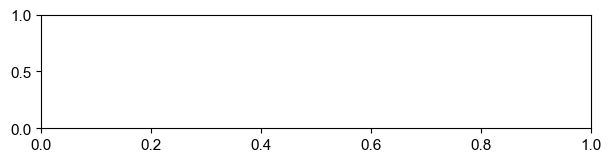

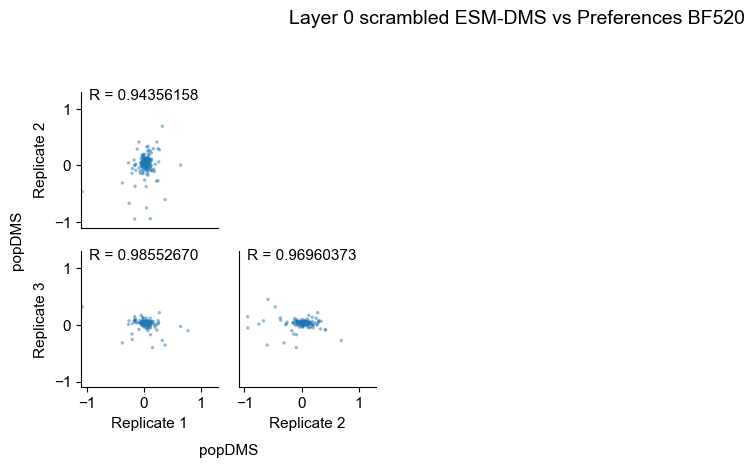

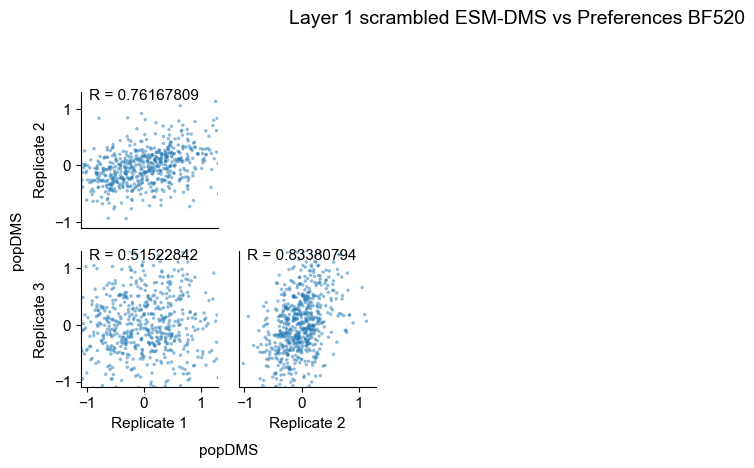

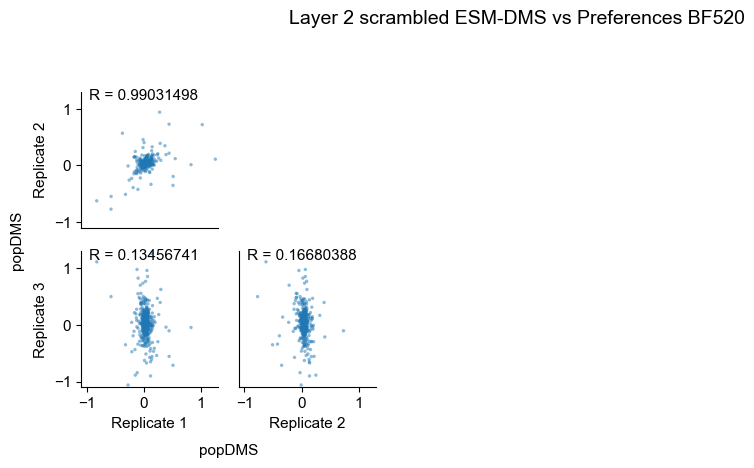

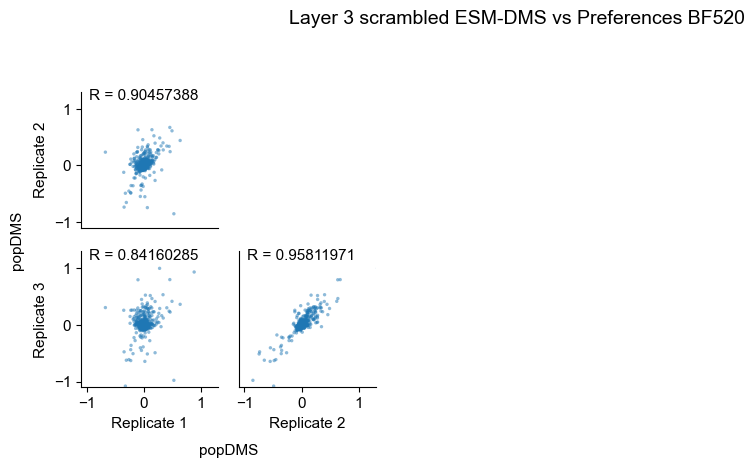

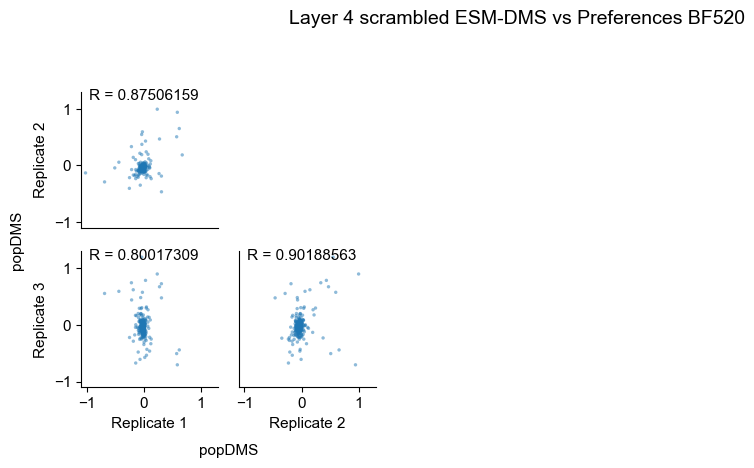

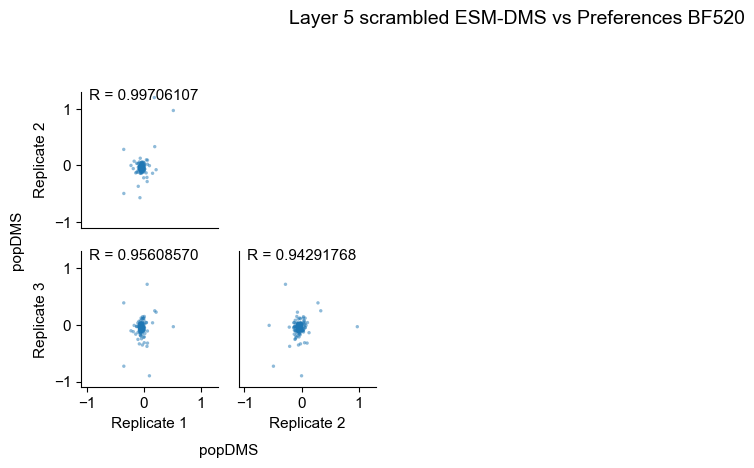

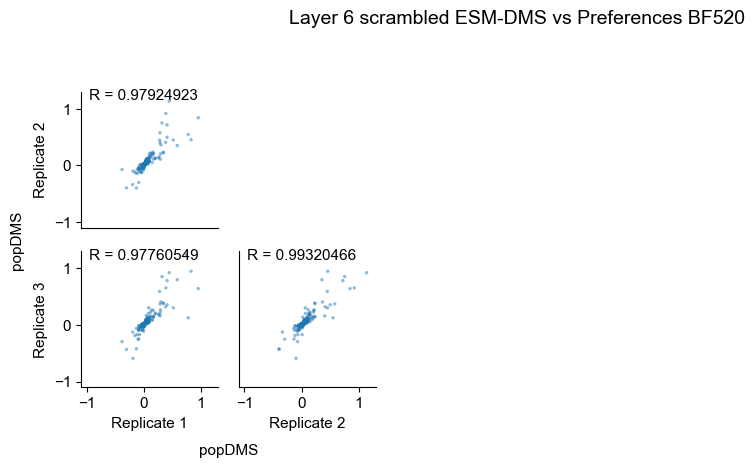

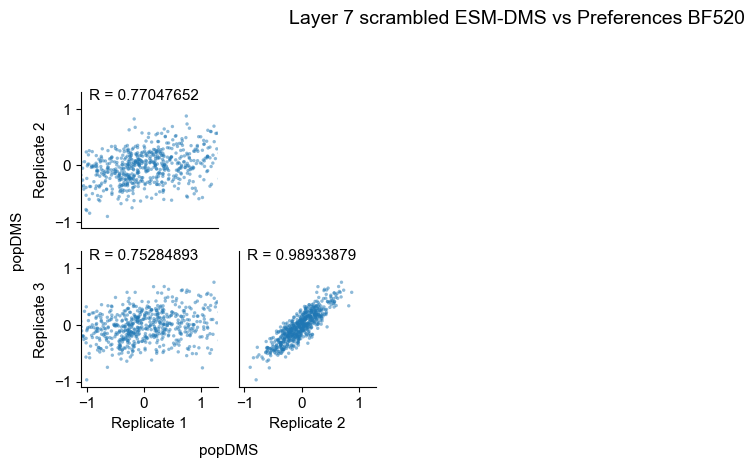

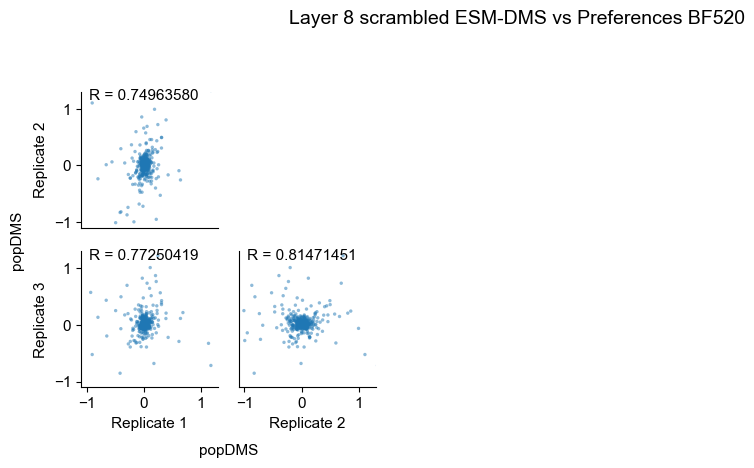

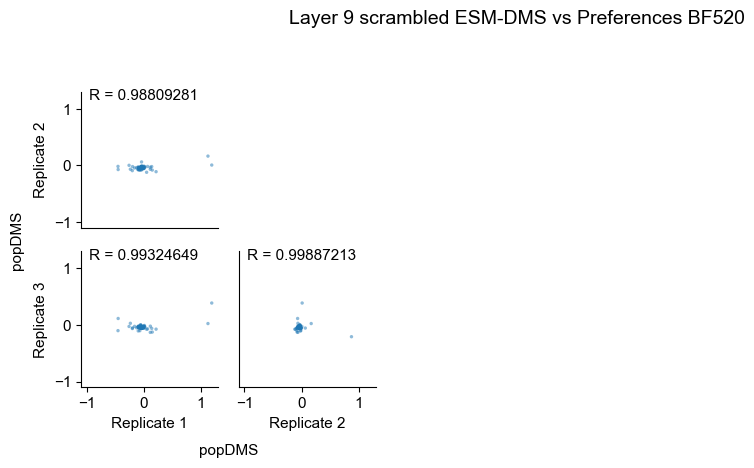

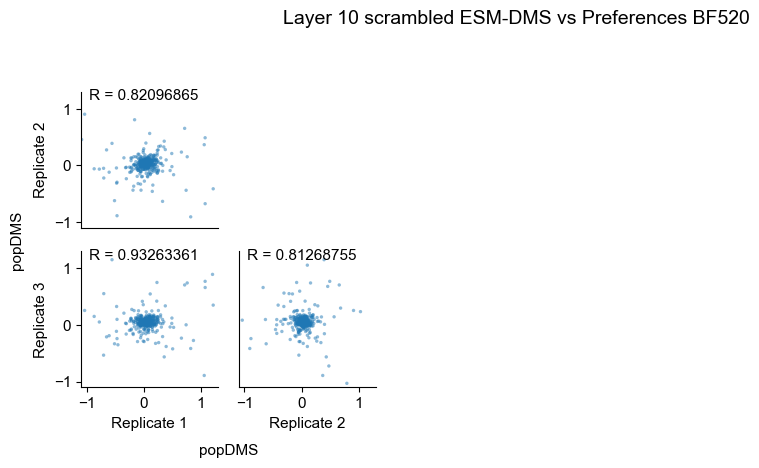

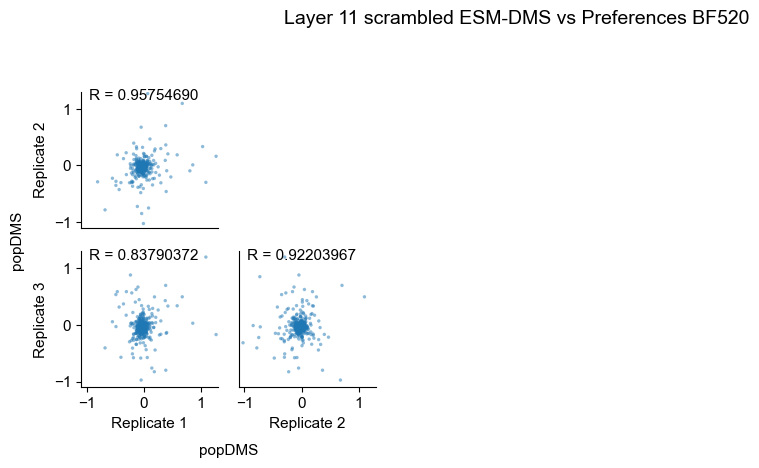

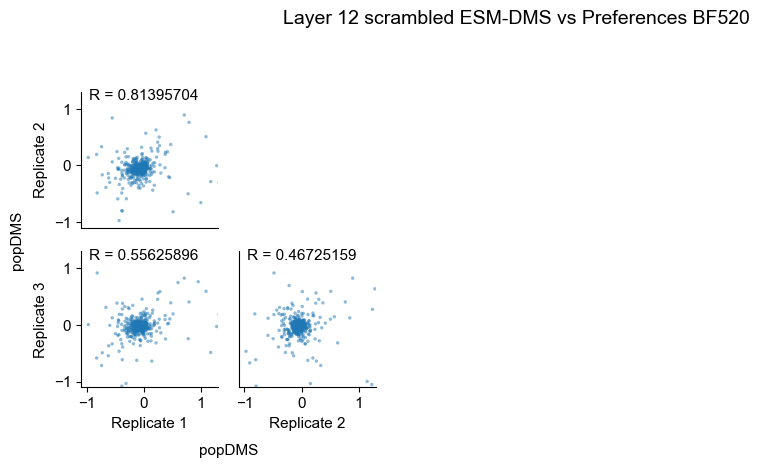

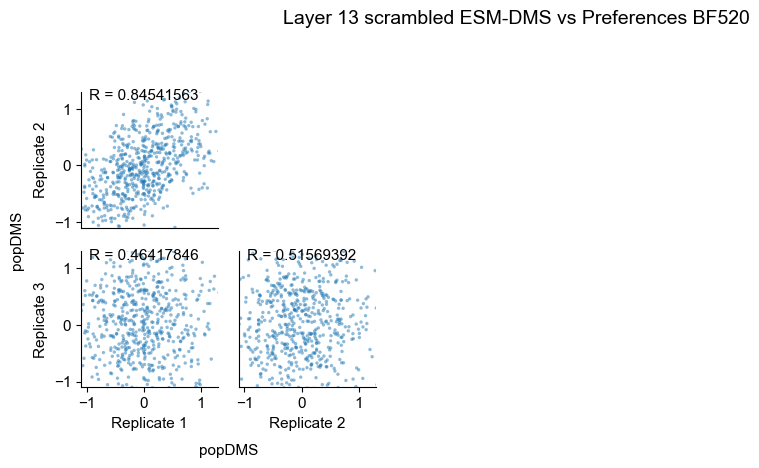

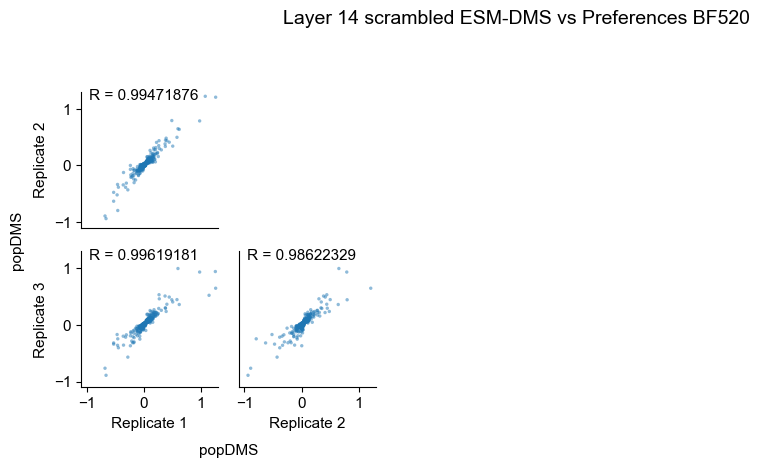

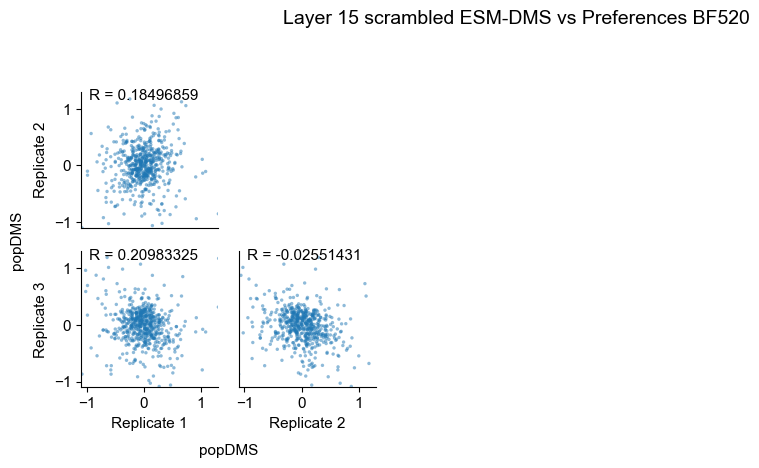

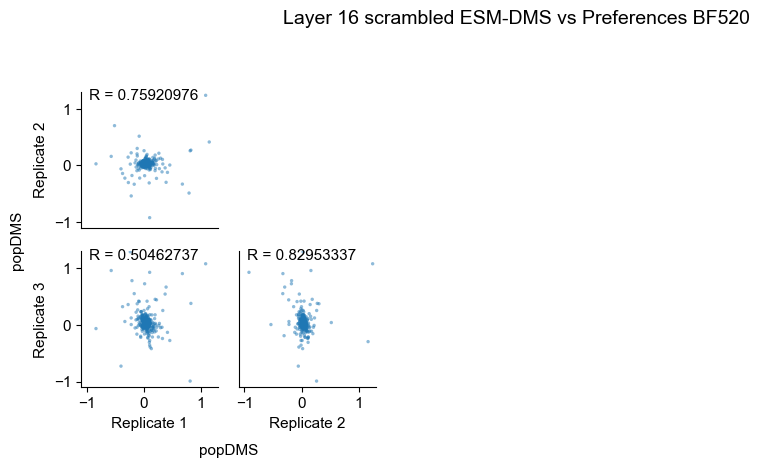

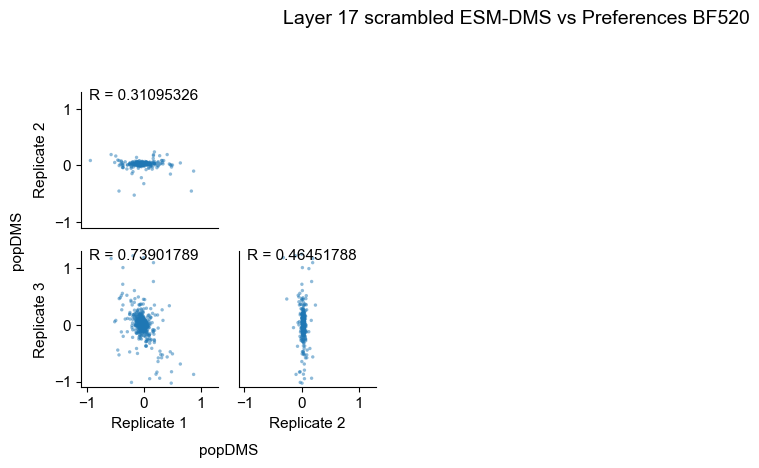

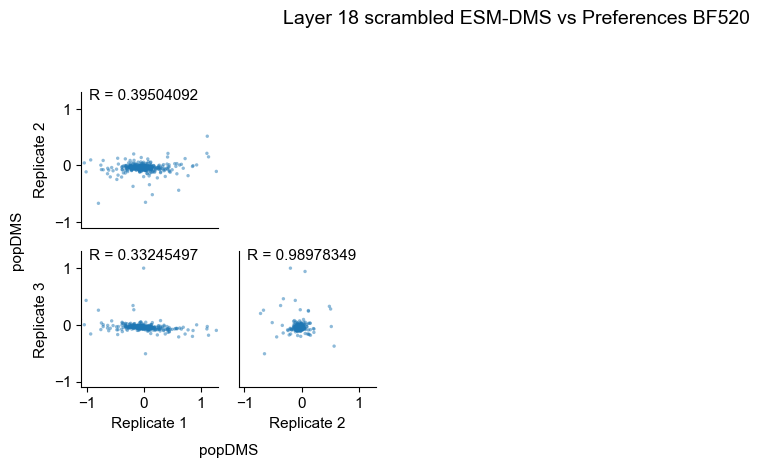

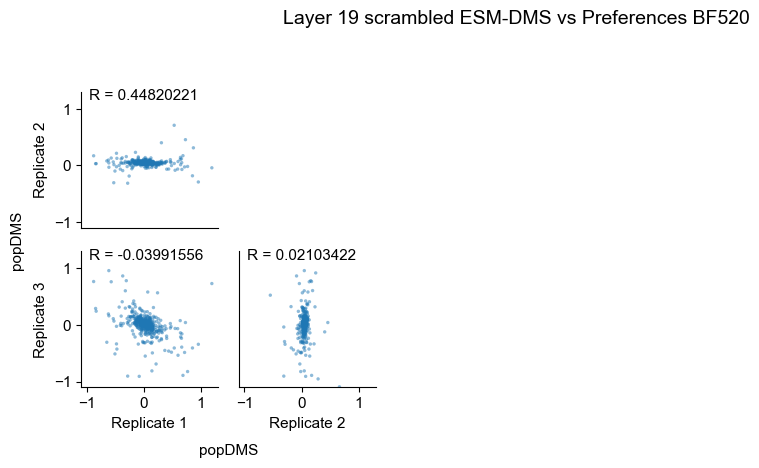

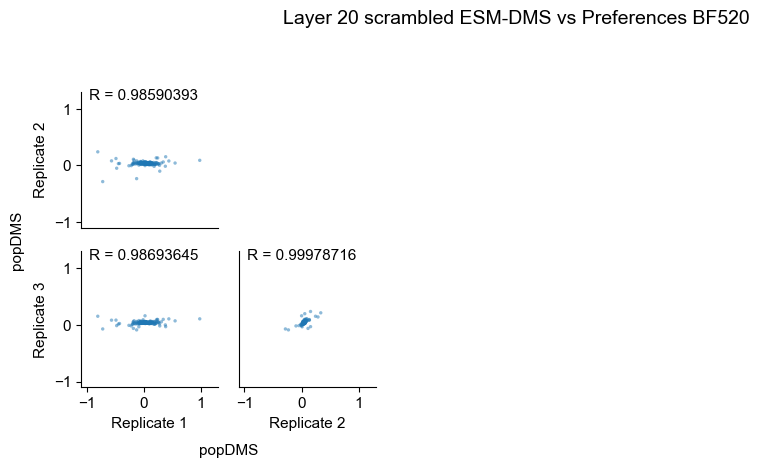

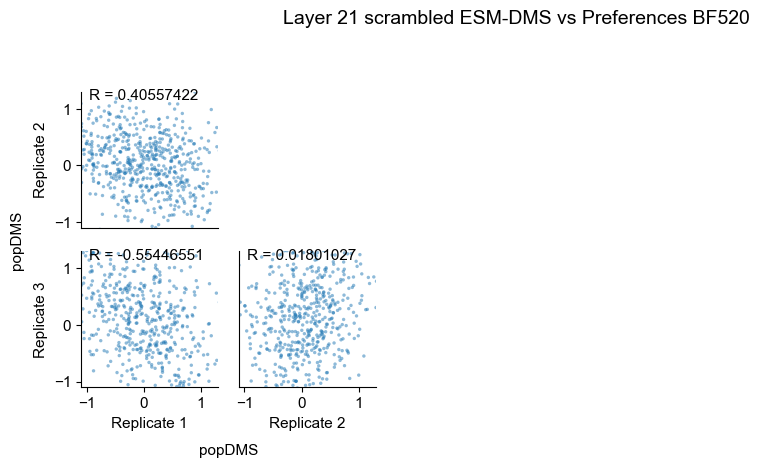

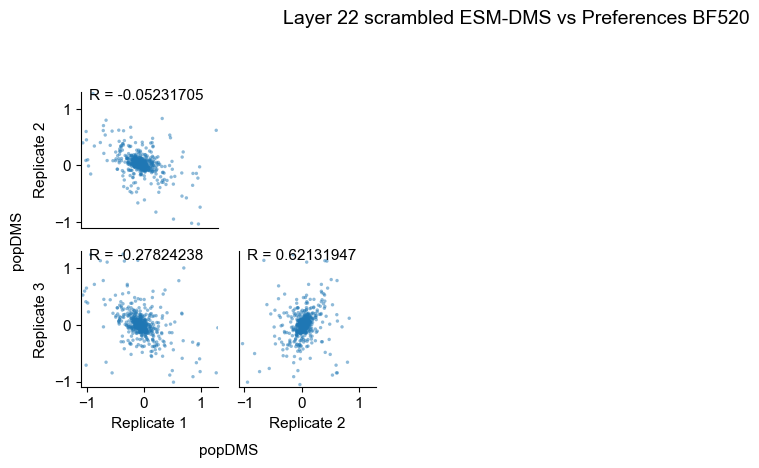

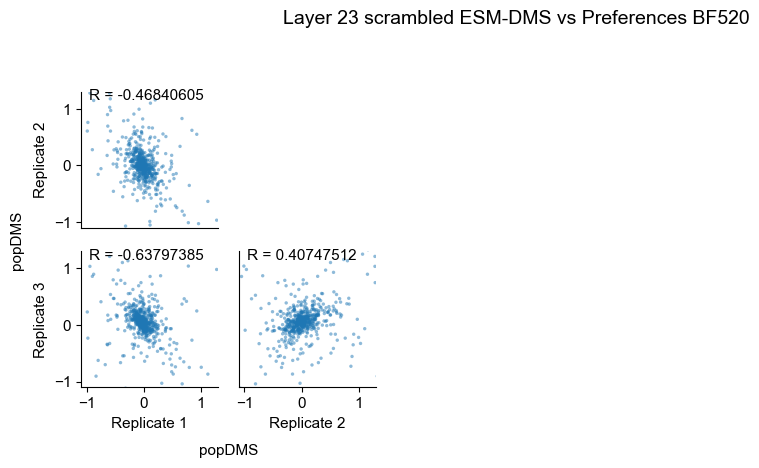

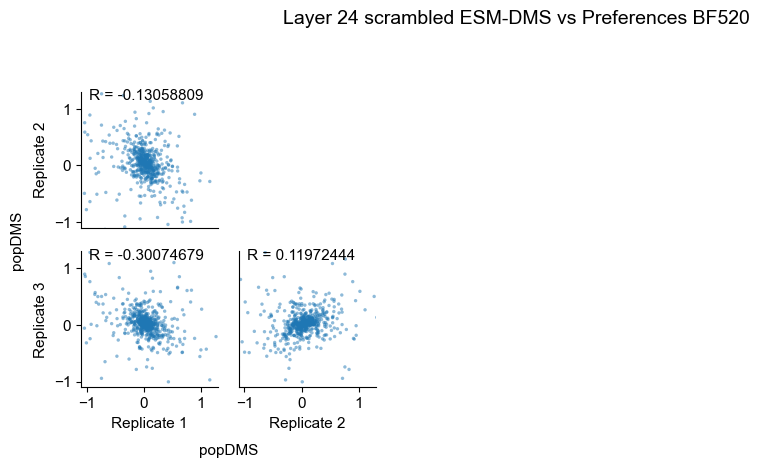

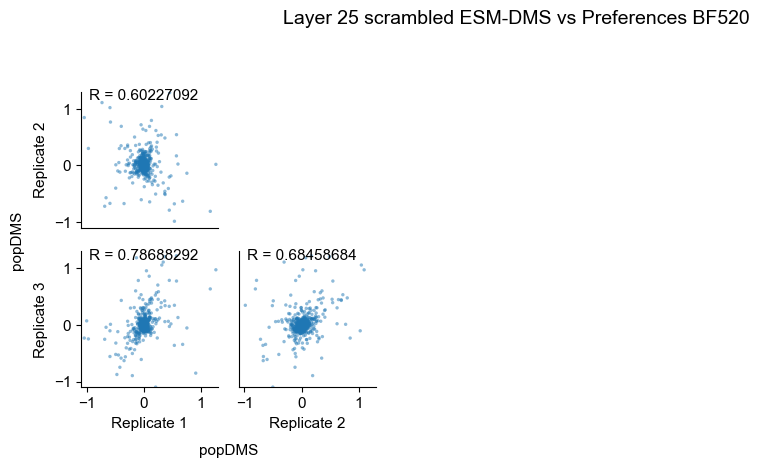

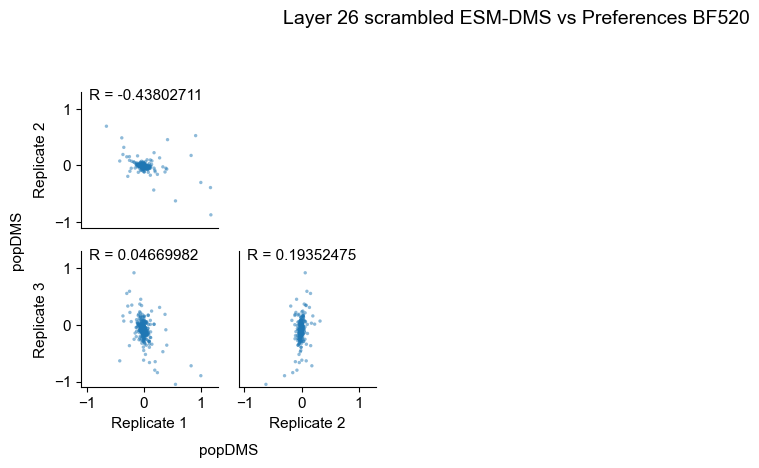

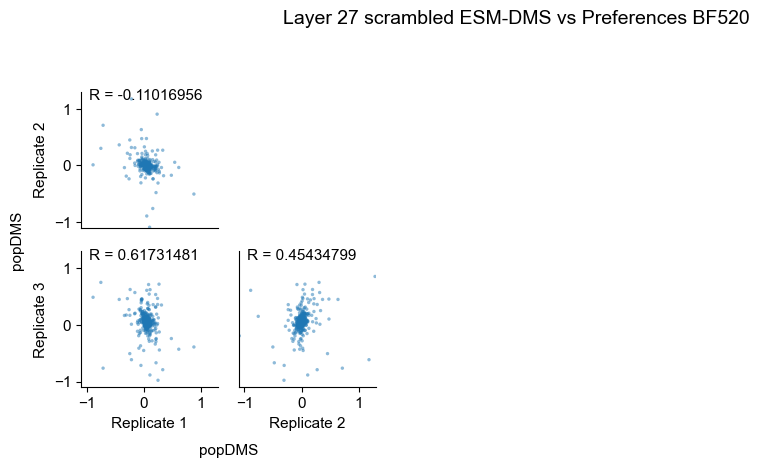

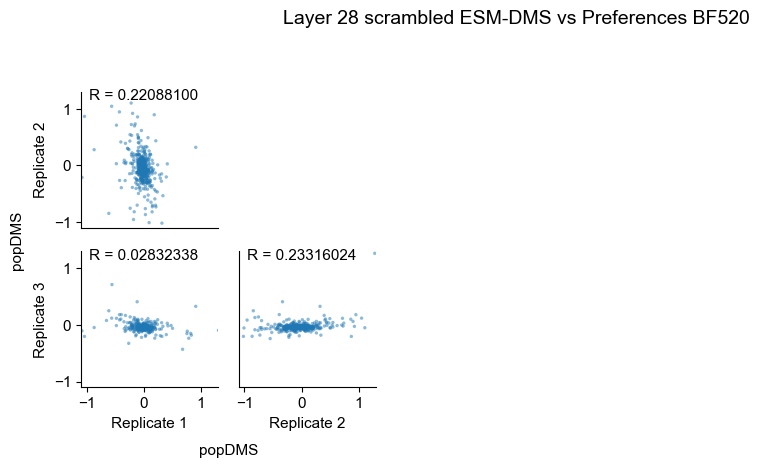

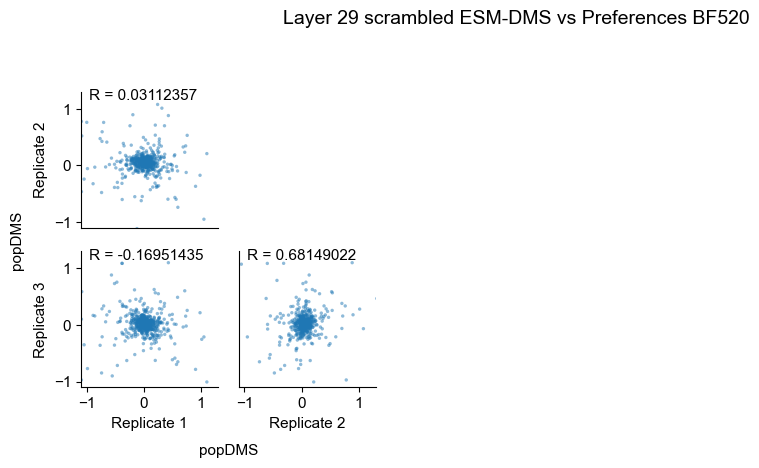

In [11]:
''' Show performance comparison across data sets '''

input_files = {
                'Flu_WSN':         ['WSN',              3],
                'Flu_A549':        ['A549',             3],
                'Flu_CCL141':      ['CCL141',           3],
                'Flu_Aichi68C':    ['Aichi68C',         2],
                'Flu_PR8':         ['PR8' ,             3],
                'Flu_MatrixM1':    ['Matrix_M1',        3],
                'H3N2 NA':         ['H3N2 NA',          2],
                'Spike':           ['Spike',            2],
                'ZIKV':            ['ZIKV',             3],
                'Perth2009':       ['Perth2009',        4],
                'Flu_MS':          ['MS',               2],
                'Flu_MxA':         ['MxA',              2],
                'Flu_MxAneg':      ['MxAneg',           2],
                'HIV_BG505':       ['HIV Env BG505' ,   3],
                'HIV_BF520':       ['HIV Env BF520' ,   3],
                'HIV_CD4_human':   ['HIV BF520 human',  2],
                'HIV_CD4_rhesus':  ['HIV BF520 rhesus', 2],
                'HIV_bnAbs_FP16':  ['HIV bnAbs FP16',   2],
                'HIV_bnAbs_FP20':  ['HIV bnAbs FP20',   2],
                'HIV_bnAbs_VRC34': ['HIV bnAbs VRC34',  2],
                'HDR_Y2H_1':       ['Y2H_1',            3],
                'HDR_Y2H_2':       ['Y2H_2',            3],
                'HDR_E3':          ['E3',               6],
                'WWdomain_YAP1':   ['YAP1',             2],
                'Ubiq_Ube4b':      ['Ube4b',            2],
                'HDR_DBR1':        ['DBR1',             2],
                'Thrombo_TpoR_1':  ['TpoR',             6],
                'Thrombo_TpoR_2':  ['TpoR_S505N',       6]
                }

print('protein\t\t\tR (pop)\tR (alt)\tR (between, Pearson/Spearman)')

pref_avg = {}
pop_avg  = {}
df_ex    = 0
ex_prot  = 'Ubiq_Ube4b'
tot_muts = 0
neg_muts = 0
n_better = 0
n_worse  = 0
n_tie    = 0
thresh   = 0.05

rps, rss = [], []  # Pearson and Spearman correlations between methods

for target_protein, info in input_files.items():
    reps = info[1]
    rep_list = ['rep_'+str(i+1) for i in range(reps)]
    path = POP_DIR + info[0] + '_selection_coefficients.csv.gz'
    df_sele = pd.read_csv(path)
    
#        print('%s\t%d' % (target_protein, len(np.unique(df_sele[COL_SITE]))))
    
    if target_protein==ex_prot:
        df_ex = df_sele.copy(deep=True)

    path = PREF_DIR + info[0] + '.csv.gz'
    df_pref = pd.read_csv(path)

    # # Try removing WT amino acids to check how this affects correlations
    # if COL_WT not in df_pref.columns:
    #     wtind = []
    #     for df_iter, df_entry in df_pref.iterrows():
    #         df_temp = df_sele[(df_sele[COL_AA]==df_entry[COL_AA]) & (df_sele[COL_SITE]==df_entry[COL_SITE])]
    #         if len(df_temp)==0:
    #             wtind.append(False)
    #         else:
    #             wtind.append(df_temp[COL_WT].values[0])
    #     df_pref['WT_indicator'] = wtind
    #     df_pref.to_csv(path, index=False)

    # df_sele = df_sele[df_sele['WT_indicator']==False]
    # df_pref = df_pref[df_pref['WT_indicator']==False]

    df_corr_pref = df_pref[[i for i in rep_list]]
    df_corr_pref = df_corr_pref.dropna()
    df_corr_sele = df_sele[[i for i in rep_list]]
    df_corr_sele = df_corr_sele.loc[~(df_corr_sele==0).all(axis=1)]

    # df_merged = pd.merge(df_pref, df_sele, on=['site', 'amino_acid'], how='inner')
    df_corr_pref = df_corr_pref[rep_list]
    df_corr_sele = df_corr_sele[rep_list]

    corr_avg_pref = (df_corr_pref.corr(method='pearson').sum().sum() - reps)/(reps**2 - reps)
    pref_avg[target_protein] = corr_avg_pref
    corr_avg_pop = (df_corr_sele.corr(method='pearson').sum().sum() - reps)/(reps**2 - reps)
    pop_avg[target_protein] = corr_avg_pop

    # corr_avg_pref = (df_corr_pref.corr(method='spearman').sum().sum() - reps)/(reps**2 - reps)
    # pref_avg[target_protein] = corr_avg_pref
    # corr_avg_pop = (df_corr_sele.corr(method='spearman').sum().sum() - reps)/(reps**2 - reps)
    # pop_avg[target_protein] = corr_avg_pop
    
    # Check correlations between popDMS and alternatives
    df_merge = pd.merge(df_pref, df_sele, how='left', left_on=['site', 'amino_acid'], right_on=['site', 'amino_acid']).dropna()
    rp, pp = st.pearsonr(df_merge['joint'], df_merge['average'])
    rs, ps = st.spearmanr(df_merge['joint'], df_merge['average'])
    
    print('%s\t%.2f\t%.2f\t%.2f\t%.2f' % (target_protein + ''.join((2-len(target_protein)//8)*['\t']),
                                            corr_avg_pop, corr_avg_pref, rp, rs))
    
    tot_muts += len(df_merge)
    neg_muts += len(df_merge[df_merge['joint']<-1])

    if corr_avg_pop-corr_avg_pref>thresh:
        n_better += 1
    elif corr_avg_pref-corr_avg_pop>thresh:
        n_worse += 1
    else:
        n_tie += 1
                                            
    rps.append(rp)
    rss.append(rs)
                                            
print('average\t\t\t%.2f\t%.2f\t%.2f\t%.2f\n' % (np.mean(list(pop_avg.values())), np.mean(list(pref_avg.values())), np.mean(rps), np.mean(rss)))

print('%d/%d = %.2e%% substantially deleterious mutations (s<-1)\n' % (neg_muts, tot_muts, 100*neg_muts/tot_muts))

print('popDMS better than regression in %d data sets' % n_better)
print('Regression better than popDMS in %d data sets' % n_worse)
print('popDMS and regression tied in %d data sets\n' % n_tie)
    
# variables
w = DOUBLE_COLUMN
h = DOUBLE_COLUMN * 1.4 / GOLDR

fig = plt.figure(figsize = (w, h))

box_t = 0.75
box_b = 0.05
box_l = 0.09
box_r = 0.98

box_dx = 0.05
box_dy = box_dx * (w / h)  # scale the box by the same amount along the x and y axes
box_y  = (box_t - box_b - 3*box_dy)/2
box_cy = 0.85*box_y
box_x  = box_y * (h / w) / 2

box_comp = dict(left=box_l,                    right=box_r,                    bottom=box_t-box_cy,                top=box_t)
box_rep1 = dict(left=box_l,                    right=box_l+2*box_x+1*box_dx,   bottom=box_t-box_cy-box_y-3*box_dy, top=box_t-box_cy-2*box_dy)
box_rep2 = dict(left=box_l+2*box_x+2.3*box_dx, right=box_l+4*box_x+3.3*box_dx, bottom=box_t-box_cy-box_y-3*box_dy, top=box_t-box_cy-2*box_dy)
box_dr2  = dict(left=box_l+4*box_x+5.0*box_dx, right=box_r,                    bottom=box_t-box_cy-box_y-3*box_dy, top=box_t-box_cy-2*box_dy)

box_mult = 3
gs_comp = gridspec.GridSpec(1, 1, wspace=0, **box_comp)
gs_rep1 = gridspec.GridSpec(2, 2, hspace=box_dy*box_mult, wspace=box_dx*box_mult, **box_rep1)
gs_rep2 = gridspec.GridSpec(2, 2, hspace=box_dy*box_mult, wspace=box_dx*box_mult, **box_rep2)
gs_dr2  = gridspec.GridSpec(1, 1, wspace=0, **box_dr2)

n_sites  = len(np.unique(df_ex[COL_SITE]))
box_ll   = 0.09
box_tt   = 0.97
box_bb   = box_t+0.6*box_dy
box_rr   = (box_tt - box_bb) * (h / w) * ((n_sites+1) / 21.5) + box_ll #((n_sites-1) / 21) + box_ll
box_heat = dict(left=box_ll, right=box_rr, bottom=box_bb, top=box_tt)
gs_heat  = gridspec.GridSpec(1, 1, wspace=0, **box_heat)
ax_heat  = plt.subplot(gs_heat[0, 0])


# Example inference with popDMS
data_set = 'HIV Env BF520'
n_reps   = 3
rep_list = ['rep_'+str(i+1) for i in range(n_reps)]

"""df_temp  = pd.read_csv(POP_DIR + data_set + '_selection_coefficients.csv.gz')[rep_list]
pop_list = []
for rep in range(1, n_reps+1):
    pop_list.append(df_temp['rep_' + str(rep)].tolist())"""


for layer in range(30):
    fig = plt.figure(figsize = (w*1.5, h*1.5))
    
    
    #All random: "/Users/dylanwells/CodingProjects/popDMS/esmDMS" + f'/testing/allrandom/layer{layer}/inference_results.pkl'
    
    with open(f"/Users/dylanwells/CodingProjects/popDMS/esmDMS/testing/allrandom/layer{layer}/inference_results.pkl", 'rb') as f:
        bf520_data = pickle.load(f)

    
    
    pop_list = []
    for rep in range(3):
        selection_coefficients = bf520_data[2][rep]
        
        # z score normalization
        selection_coefficients = (selection_coefficients - np.mean(selection_coefficients)) / np.std(selection_coefficients)
        
        pop_list.append(selection_coefficients.tolist())
    
        #print(selection_coefficients[:10])


    df_temp = pd.read_csv(PREF_DIR + data_set + '.csv.gz')[rep_list]
    df_temp = df_temp[~(df_temp==0).any(axis=1)]
    pref_list = []
    for rep in range(1, n_reps+1):
        pref_list.append(df_temp['rep_' + str(rep)].tolist())

    scatterprops = dict(alpha=0.5, edgecolor='none', s=SMALLSIZEDOT)


    ticks  = []
    vticks = [-1, 0, 1]
    lim    = [-1.1, 1.3]
    td     = (lim[1] - lim[0])*0.06

    n_digits = 2
    for i in range(n_reps):
        for j in range(i+1, n_reps):
            #corr = round(st.pearsonr(pop_list[i], pop_list[j])[0], n_digits)
            corr = st.pearsonr(pop_list[i], pop_list[j])[0]
            ax2_sub = 0
            if i == 0 and j == 1:
                ax2_sub = plt.subplot(gs_rep1[0, 0])
                ax2_sub.set_ylabel('Replicate 2', fontsize = SIZELABEL)
                ax2_sub.set_xticks(ticks)
                ax2_sub.set_yticks(vticks)

            if i == 0 and j == 2:
                ax2_sub = plt.subplot(gs_rep1[1, 0])
                ax2_sub.set_ylabel('Replicate 3', fontsize = SIZELABEL)
                ax2_sub.set_xlabel('Replicate 1', fontsize = SIZELABEL)
                ax2_sub.set_xticks(vticks)
                ax2_sub.set_yticks(vticks)

            if i == 1 and j == 2:
                ax2_sub = plt.subplot(gs_rep1[1, 1])
                ax2_sub.set_xlabel('Replicate 2', fontsize = SIZELABEL)
                ax2_sub.set_xticks(vticks)
                ax2_sub.set_yticks(ticks)

            ax2_sub.scatter(pop_list[i], pop_list[j], **scatterprops)
            ax2_sub.text(lim[0]+td, lim[1]-td, 'R = %.8f' % corr, fontsize = SIZELABEL)

            # ax2_sub.set_xticks(ticks)
            # ax2_sub.set_yticks(ticks)
            ax2_sub.set_xlim(lim)
            ax2_sub.set_ylim(lim)

            ax2_sub.spines['right'].set_visible(False)
            ax2_sub.spines[ 'top' ].set_visible(False)
            
    ddx = 0.06
    ddy = ddx * (w / h)
    fig.text(box_rep1['left']-ddx, (box_rep1['top']+box_rep1['bottom'])/2,   s='popDMS', rotation=90, ha='center', va='center', **DEF_LABELPROPS, transform=fig.transFigure)
    fig.text((box_rep1['left']+box_rep1['right'])/2, box_rep1['bottom']-ddy, s='popDMS', rotation=0,  ha='center', va='center', **DEF_LABELPROPS, transform=fig.transFigure)

    # Scatter plot of sample experiment of Enrichment ratio

    ticks  = []
    vticks = [0, 0.5, 1]
    lim    = [0, 1]
    td     = (lim[1] - lim[0])*0.05

    # for i in range(len(pref_list)):
    #     print(np.min(pref_list[i]), np.max(pref_list[i]))
        # print(np.min(np.log10(pref_list[i])), np.max(np.log10(pref_list[i])))

    
            
    ddx = 0.06
    ddy = ddx * (w / h)

    fig_title = f"{layer}_esmDMS_vs_preferences_comparison_BF520.png"
    
    fig.suptitle(f'Layer {layer} scrambled ESM-DMS vs Preferences BF520', fontsize=14, y=0.5)
    
    
    fig.savefig(FIG_DIR + fig_title, **FIGPROPS)

[-0.02429344 -0.0165418   0.00643216 -0.00176376 -0.00096248 -0.01954963
 -0.00561232  0.00495643 -0.05202962  0.02161409]
[-0.02430171 -0.01654244  0.00642589 -0.00174949 -0.00095983 -0.01955883
 -0.00561375  0.00494166 -0.05203204  0.02160152]
[-0.02430816 -0.01654958  0.00642965 -0.00177801 -0.00096094 -0.01955681
 -0.005609    0.00494897 -0.05204402  0.02160168]


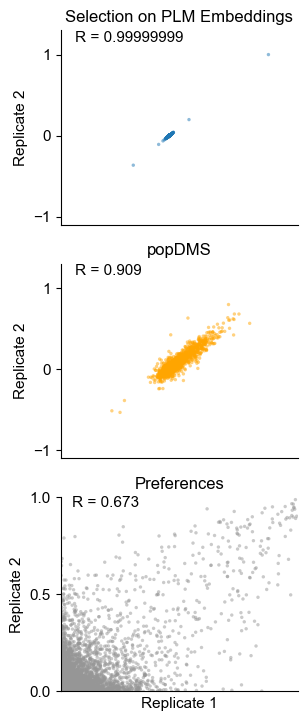

In [60]:
"""''' Show performance comparison across data sets '''

input_files = {
                'Flu_WSN':         ['WSN',              3],
                'Flu_A549':        ['A549',             3],
                'Flu_CCL141':      ['CCL141',           3],
                'Flu_Aichi68C':    ['Aichi68C',         2],
                'Flu_PR8':         ['PR8' ,             3],
                'Flu_MatrixM1':    ['Matrix_M1',        3],
                'H3N2 NA':         ['H3N2 NA',          2],
                'Spike':           ['Spike',            2],
                'ZIKV':            ['ZIKV',             3],
                'Perth2009':       ['Perth2009',        4],
                'Flu_MS':          ['MS',               2],
                'Flu_MxA':         ['MxA',              2],
                'Flu_MxAneg':      ['MxAneg',           2],
                'HIV_BG505':       ['HIV Env BG505' ,   3],
                'HIV_BF520':       ['HIV Env BF520' ,   3],
                'HIV_CD4_human':   ['HIV BF520 human',  2],
                'HIV_CD4_rhesus':  ['HIV BF520 rhesus', 2],
                'HIV_bnAbs_FP16':  ['HIV bnAbs FP16',   2],
                'HIV_bnAbs_FP20':  ['HIV bnAbs FP20',   2],
                'HIV_bnAbs_VRC34': ['HIV bnAbs VRC34',  2],
                'HDR_Y2H_1':       ['Y2H_1',            3],
                'HDR_Y2H_2':       ['Y2H_2',            3],
                'HDR_E3':          ['E3',               6],
                'WWdomain_YAP1':   ['YAP1',             2],
                'Ubiq_Ube4b':      ['Ube4b',            2],
                'HDR_DBR1':        ['DBR1',             2],
                'Thrombo_TpoR_1':  ['TpoR',             6],
                'Thrombo_TpoR_2':  ['TpoR_S505N',       6]
                }

print('protein\t\t\tR (pop)\tR (alt)\tR (between, Pearson/Spearman)')

pref_avg = {}
pop_avg  = {}
df_ex    = 0
ex_prot  = 'Ubiq_Ube4b'
tot_muts = 0
neg_muts = 0
n_better = 0
n_worse  = 0
n_tie    = 0
thresh   = 0.05

rps, rss = [], []  # Pearson and Spearman correlations between methods

for target_protein, info in input_files.items():
    reps = info[1]
    rep_list = ['rep_'+str(i+1) for i in range(reps)]
    path = POP_DIR + info[0] + '_selection_coefficients.csv.gz'
    df_sele = pd.read_csv(path)
    
#        print('%s\t%d' % (target_protein, len(np.unique(df_sele[COL_SITE]))))
    
    if target_protein==ex_prot:
        df_ex = df_sele.copy(deep=True)

    path = PREF_DIR + info[0] + '.csv.gz'
    df_pref = pd.read_csv(path)

    # # Try removing WT amino acids to check how this affects correlations
    # if COL_WT not in df_pref.columns:
    #     wtind = []
    #     for df_iter, df_entry in df_pref.iterrows():
    #         df_temp = df_sele[(df_sele[COL_AA]==df_entry[COL_AA]) & (df_sele[COL_SITE]==df_entry[COL_SITE])]
    #         if len(df_temp)==0:
    #             wtind.append(False)
    #         else:
    #             wtind.append(df_temp[COL_WT].values[0])
    #     df_pref['WT_indicator'] = wtind
    #     df_pref.to_csv(path, index=False)

    # df_sele = df_sele[df_sele['WT_indicator']==False]
    # df_pref = df_pref[df_pref['WT_indicator']==False]

    df_corr_pref = df_pref[[i for i in rep_list]]
    df_corr_pref = df_corr_pref.dropna()
    df_corr_sele = df_sele[[i for i in rep_list]]
    df_corr_sele = df_corr_sele.loc[~(df_corr_sele==0).all(axis=1)]

    # df_merged = pd.merge(df_pref, df_sele, on=['site', 'amino_acid'], how='inner')
    df_corr_pref = df_corr_pref[rep_list]
    df_corr_sele = df_corr_sele[rep_list]

    corr_avg_pref = (df_corr_pref.corr(method='pearson').sum().sum() - reps)/(reps**2 - reps)
    pref_avg[target_protein] = corr_avg_pref
    corr_avg_pop = (df_corr_sele.corr(method='pearson').sum().sum() - reps)/(reps**2 - reps)
    pop_avg[target_protein] = corr_avg_pop

    # corr_avg_pref = (df_corr_pref.corr(method='spearman').sum().sum() - reps)/(reps**2 - reps)
    # pref_avg[target_protein] = corr_avg_pref
    # corr_avg_pop = (df_corr_sele.corr(method='spearman').sum().sum() - reps)/(reps**2 - reps)
    # pop_avg[target_protein] = corr_avg_pop
    
    # Check correlations between popDMS and alternatives
    df_merge = pd.merge(df_pref, df_sele, how='left', left_on=['site', 'amino_acid'], right_on=['site', 'amino_acid']).dropna()
    rp, pp = st.pearsonr(df_merge['joint'], df_merge['average'])
    rs, ps = st.spearmanr(df_merge['joint'], df_merge['average'])
    
    print('%s\t%.2f\t%.2f\t%.2f\t%.2f' % (target_protein + ''.join((2-len(target_protein)//8)*['\t']),
                                            corr_avg_pop, corr_avg_pref, rp, rs))
    
    tot_muts += len(df_merge)
    neg_muts += len(df_merge[df_merge['joint']<-1])

    if corr_avg_pop-corr_avg_pref>thresh:
        n_better += 1
    elif corr_avg_pref-corr_avg_pop>thresh:
        n_worse += 1
    else:
        n_tie += 1
                                            
    rps.append(rp)
    rss.append(rs)
                                            
print('average\t\t\t%.2f\t%.2f\t%.2f\t%.2f\n' % (np.mean(list(pop_avg.values())), np.mean(list(pref_avg.values())), np.mean(rps), np.mean(rss)))

print('%d/%d = %.2e%% substantially deleterious mutations (s<-1)\n' % (neg_muts, tot_muts, 100*neg_muts/tot_muts))

print('popDMS better than regression in %d data sets' % n_better)
print('Regression better than popDMS in %d data sets' % n_worse)
print('popDMS and regression tied in %d data sets\n' % n_tie)
    
# variables
w = DOUBLE_COLUMN
h = DOUBLE_COLUMN * 1.4 / GOLDR

fig = plt.figure(figsize = (w, h))

box_t = 0.75
box_b = 0.05
box_l = 0.09
box_r = 0.98

box_dx = 0.05
box_dy = box_dx * (w / h)  # scale the box by the same amount along the x and y axes
box_y  = (box_t - box_b - 3*box_dy)/2
box_cy = 0.85*box_y
box_x  = box_y * (h / w) / 2

box_comp = dict(left=box_l,                    right=box_r,                    bottom=box_t-box_cy,                top=box_t)
box_rep1 = dict(left=box_l,                    right=box_l+2*box_x+1*box_dx,   bottom=box_t-box_cy-box_y-3*box_dy, top=box_t-box_cy-2*box_dy)
box_rep2 = dict(left=box_l+2*box_x+2.3*box_dx, right=box_l+4*box_x+3.3*box_dx, bottom=box_t-box_cy-box_y-3*box_dy, top=box_t-box_cy-2*box_dy)
box_dr2  = dict(left=box_l+4*box_x+5.0*box_dx, right=box_r,                    bottom=box_t-box_cy-box_y-3*box_dy, top=box_t-box_cy-2*box_dy)

box_mult = 3
gs_comp = gridspec.GridSpec(1, 1, wspace=0, **box_comp)
gs_rep1 = gridspec.GridSpec(2, 2, hspace=box_dy*box_mult, wspace=box_dx*box_mult, **box_rep1)
gs_rep2 = gridspec.GridSpec(2, 2, hspace=box_dy*box_mult, wspace=box_dx*box_mult, **box_rep2)
gs_dr2  = gridspec.GridSpec(1, 1, wspace=0, **box_dr2)

n_sites  = len(np.unique(df_ex[COL_SITE]))
box_ll   = 0.09
box_tt   = 0.97
box_bb   = box_t+0.6*box_dy
box_rr   = (box_tt - box_bb) * (h / w) * ((n_sites+1) / 21.5) + box_ll #((n_sites-1) / 21) + box_ll
box_heat = dict(left=box_ll, right=box_rr, bottom=box_bb, top=box_tt)
gs_heat  = gridspec.GridSpec(1, 1, wspace=0, **box_heat)
ax_heat  = plt.subplot(gs_heat[0, 0])

"""
# Example inference with popDMS


data_set = 'HIV Env BF520'
n_reps   = 3
rep_list = ['rep_'+str(i+1) for i in range(n_reps)]

df_temp  = pd.read_csv(POP_DIR + data_set + '_selection_coefficients.csv.gz')[rep_list]
pop_list = []
for rep in range(1, n_reps+1):
    pop_list.append(df_temp['rep_' + str(rep)].tolist())



layer = 30
# Make a figure with 3 subplots showing pairwise comparisons between replicates

#fig = plt.figure(figsize = (w+1.5, h/2))
fig = plt.figure(figsize = (h/2, w+1.5))

with open("/Users/dylanwells/CodingProjects/popDMS/esmDMS" + f'/data/inference_results/layer{layer}/inference_results.pkl', 'rb') as f:
    bf520_data = pickle.load(f)


esm_list = []
for rep in range(3):
    selection_coefficients = bf520_data[-1][rep][1]
    
    
    selection_coefficients = selection_coefficients / np.max(np.abs(selection_coefficients))
    
    esm_list.append(selection_coefficients.tolist())

    print(selection_coefficients[:10])


df_temp = pd.read_csv(PREF_DIR + data_set + '.csv.gz')[rep_list]
df_temp = df_temp[~(df_temp==0).any(axis=1)]
pref_list = []
for rep in range(1, n_reps+1):
    pref_list.append(df_temp['rep_' + str(rep)].tolist())

scatterprops = dict(alpha=0.5, edgecolor='none', s=SMALLSIZEDOT)


ticks  = []
vticks = [-1, 0, 1]
lim    = [-1.1, 1.3]
td     = (lim[1] - lim[0])*0.06

n_digits = 2
for i in range(n_reps):
    for j in range(i+1, n_reps):
        #corr = round(st.pearsonr(pop_list[i], pop_list[j])[0], n_digits)
        corr = st.pearsonr(esm_list[i], esm_list[j])[0]
        ax2_sub = 0
        if i == 0 and j == 1:
            # make the subplot the second of the 1x3 grid
            ax2_sub = plt.subplot(3, 1, 1)
            #ax2_sub.set_xlabel('Replicate 1', fontsize = SIZELABEL)
            ax2_sub.set_ylabel('Replicate 2', fontsize = SIZELABEL)
            ax2_sub.set_xticks(ticks)
            ax2_sub.set_yticks(vticks)

            ax2_sub.scatter(esm_list[i], esm_list[j], **scatterprops)
            ax2_sub.text(lim[0]+td, lim[1]-td, 'R = %.8f' % corr, fontsize = SIZELABEL)

            # ax2_sub.set_xticks(ticks)
            # ax2_sub.set_yticks(ticks)
            ax2_sub.set_xlim(lim)
            ax2_sub.set_ylim(lim)

            ax2_sub.spines['right'].set_visible(False)
            ax2_sub.spines[ 'top' ].set_visible(False)
            title = 'Selection on PLM Embeddings'
            ax2_sub.set_title(title, fontsize=12)
        
n_digits = 2
for i in range(n_reps):
    for j in range(i+1, n_reps):
        #corr = round(st.pearsonr(pop_list[i], pop_list[j])[0], n_digits)
        corr = st.pearsonr(pop_list[i], pop_list[j])[0]
        ax2_sub = 0
        if i == 0 and j == 1:
            # make the subplot the second of the 1x3 grid
            ax2_sub = plt.subplot(3, 1, 2)
            #ax2_sub.set_xlabel('Replicate 1', fontsize = SIZELABEL)
            ax2_sub.set_ylabel('Replicate 2', fontsize = SIZELABEL)
            
            ax2_sub.set_xticks(ticks)
            ax2_sub.set_yticks(vticks)

            ax2_sub.scatter(pop_list[i], pop_list[j], **scatterprops, color="orange")
            ax2_sub.text(lim[0]+td, lim[1]-td, 'R = %.3f' % corr, fontsize = SIZELABEL)

            # ax2_sub.set_xticks(ticks)
            # ax2_sub.set_yticks(ticks)
            ax2_sub.set_xlim(lim)
            ax2_sub.set_ylim(lim)

            ax2_sub.spines['right'].set_visible(False)
            ax2_sub.spines[ 'top' ].set_visible(False)
            title = 'popDMS'
            ax2_sub.set_title(title, fontsize=12)
        
ddx = 0.06
ddy = ddx * (w / h)
#fig.text(box_rep1['left']-ddx, (box_rep1['top']+box_rep1['bottom'])/2,   s='Selection on Embeddings', rotation=90, ha='center', 
#         va='center', **DEF_LABELPROPS, transform=fig.transFigure)
#fig.text((box_rep1['left']+box_rep1['right'])/2, box_rep1['bottom']-ddy, s='Selection on Embeddings', rotation=0,  ha='center', 
#         va='center', **DEF_LABELPROPS, transform=fig.transFigure)

# Scatter plot of sample experiment of Enrichment ratio

ticks  = []
vticks = [0, 0.5, 1]
lim    = [0, 1]
td     = (lim[1] - lim[0])*0.05

# for i in range(len(pref_list)):
#     print(np.min(pref_list[i]), np.max(pref_list[i]))
    # print(np.min(np.log10(pref_list[i])), np.max(np.log10(pref_list[i])))

for i in range(3):
    for j in range(i + 1, 3):
        corr = round(st.pearsonr(pref_list[i], pref_list[j])[0], 3)
        # corr = round(st.pearsonr(np.log10(pref_list[i]), np.log10(pref_list[j]))[0], n_digits)
        ax3_sub = 0
        if i == 0 and j == 1:
            ax3_sub = plt.subplot(3, 1, 3)
            ax3_sub.set_xlabel('Replicate 1', fontsize = SIZELABEL)
            ax3_sub.set_ylabel('Replicate 2', fontsize = SIZELABEL)
            ax3_sub.set_xticks(ticks)
            ax3_sub.set_yticks(vticks)


            ax3_sub.scatter(pref_list[i], pref_list[j], c=C_PREF, **scatterprops)
            # ax3_sub.scatter(np.log10(pref_list[i]), np.log10(pref_list[j]), c=C_PREF, **scatterprops)
            ax3_sub.text(lim[0]+td, lim[1]-td, 'R = %.3f' % corr, fontsize = SIZELABEL)

            # ax3_sub.set_xticks(ticks)
            # ax3_sub.set_yticks(ticks)
            ax3_sub.set_xlim(lim)
            ax3_sub.set_ylim(lim)

            ax3_sub.spines['right'].set_visible(False)
            ax3_sub.spines[ 'top' ].set_visible(False)
            title = 'Preferences'
            ax3_sub.set_title(title, fontsize=12)
            
        
ddx = 0.2
ddy = ddx * (w / h)
#fig.text(box_rep2['left']-ddx, (box_rep2['top']+box_rep2['bottom'])/2,   s='Preferences', rotation=90, ha='center', va='center', **DEF_LABELPROPS, transform=fig.transFigure)
#fig.text((box_rep2['left']+box_rep2['right'])/2, box_rep2['bottom']-ddy, s='Preferences', rotation=0,  ha='center', va='center', **DEF_LABELPROPS, transform=fig.transFigure)

fig_title = f"{layer}_esmDMS_vs_preferences_comparison_BF520.png"

fig.savefig(FIG_DIR + fig_title, **FIGPROPS)

In [ ]:
whole_df = pd.read_pickle(pwd + '/data/sequence_data/all_reps_BF520_protein_embeddings.pkl')

reload(popDMS)

layer_results = analyze_layers(whole_df)

In [64]:
with open("/Users/dylanwells/CodingProjects/popDMS/esmDMS" + f'/data/inference_results/test_random_counts/layer{layer}/inference_results.pkl', 'rb') as f:
        bf520_data = pickle.load(f)

In [65]:
print(bf520_data)

[[array([ 1.49826372e-05, -1.55041399e-04,  1.78729034e-04,  2.19308586e-04,
       -2.34815252e-04, -1.57540205e-04, -6.84303539e-05,  1.12319037e-04,
       -6.89207617e-05, -1.41653680e-04,  9.47255729e-05,  4.61271060e-05,
        4.91024376e-05,  6.38983781e-05,  1.09718666e-04, -1.77098969e-06,
       -8.36541680e-05, -7.89460015e-05,  1.89420118e-04,  1.90195267e-04,
        1.14259438e-04,  6.66331579e-05,  4.59140765e-05, -8.05877970e-06,
        1.18529859e-04, -1.19458592e-04, -3.48168924e-04,  5.50525646e-05,
       -1.08678303e-04,  1.22483944e-04, -2.24193661e-04,  7.52136276e-05,
       -6.42558336e-05, -2.14616130e-05,  1.30763280e-04, -1.35207732e-04,
       -8.32529027e-05,  2.45702591e-04,  1.24524845e-04, -8.97141825e-05,
       -5.06002361e-05, -1.04571255e-05,  8.93110289e-05,  1.36050207e-05,
        2.11525974e-04,  9.58529725e-06, -4.88295094e-05,  4.26469946e-05,
       -1.56910445e-04,  2.53691178e-04, -1.02262970e-04,  1.23864522e-05,
        5.19229513e-06,